project start 

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 

warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv("insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [4]:
df.shape

(1338, 7)

In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:

df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [9]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

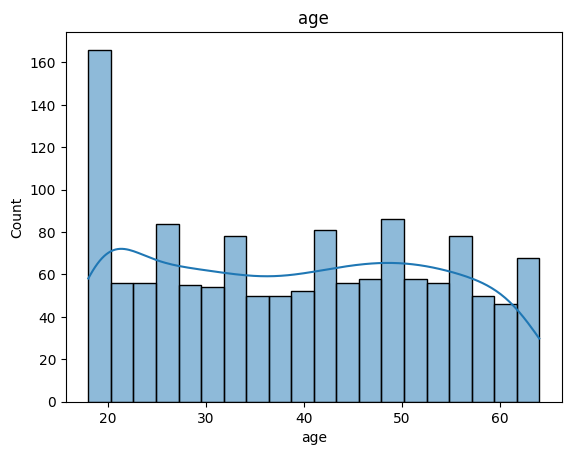

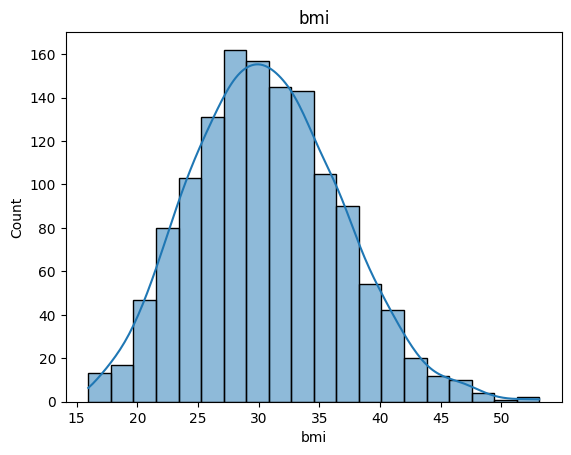

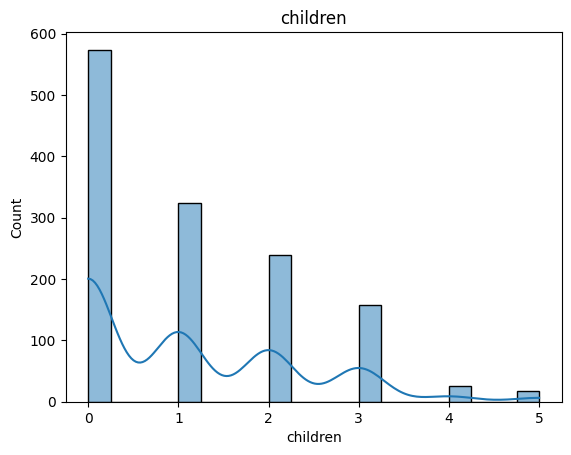

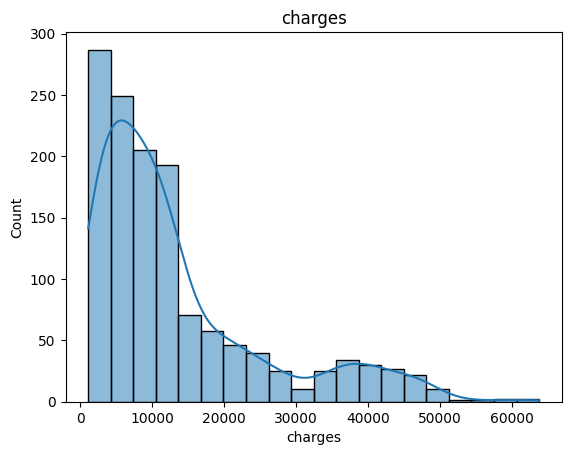

In [10]:
numeric_columns=df[['age',  'bmi', 'children',  'charges']]
for col in numeric_columns:
    plt.Figure(figsize=(6,4))
    sns.histplot(df[col],kde = True, bins=20)
    plt.title(col)
    plt.show()

create count plot for children

<Axes: xlabel='children', ylabel='count'>

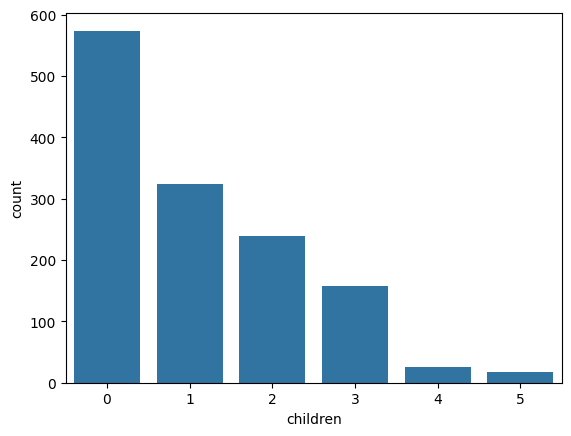

In [11]:
sns.countplot(x=df['children'])

create the count plote for gender

<Axes: xlabel='sex', ylabel='count'>

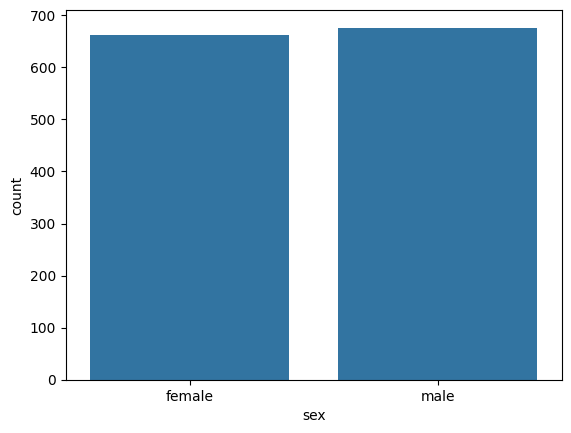

In [12]:
sns.countplot(x=df['sex'])

find smoker people and not smoker

<Axes: xlabel='smoker', ylabel='count'>

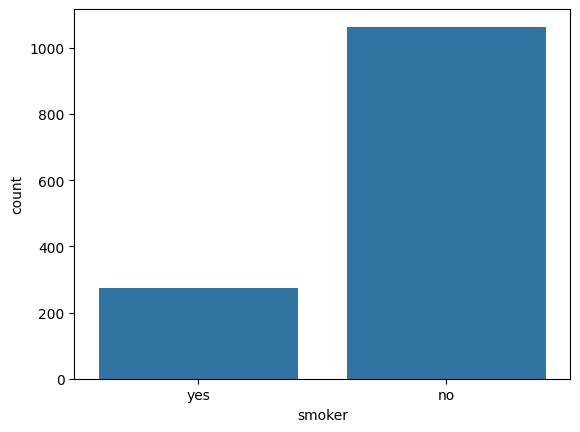

In [13]:
sns.countplot(x=df['smoker'])

create box plot for numeric columns

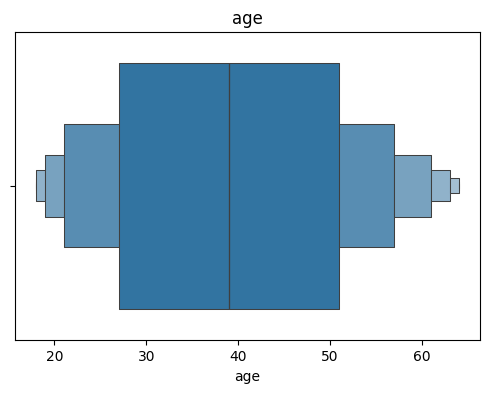

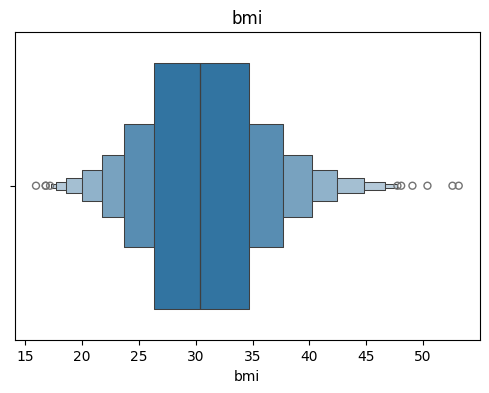

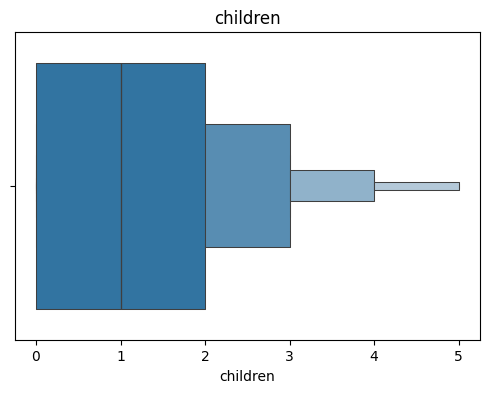

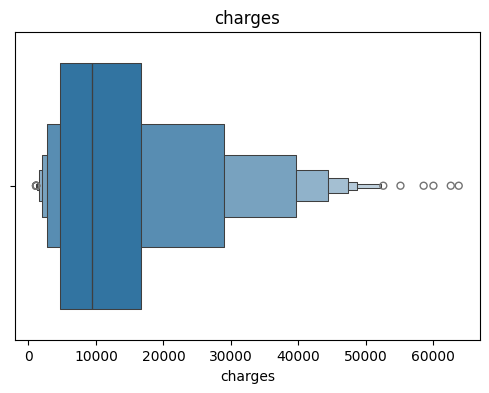

In [14]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxenplot(x=df[col])
    plt.title(col)
    plt.show()

create heat map check co relations

<Axes: >

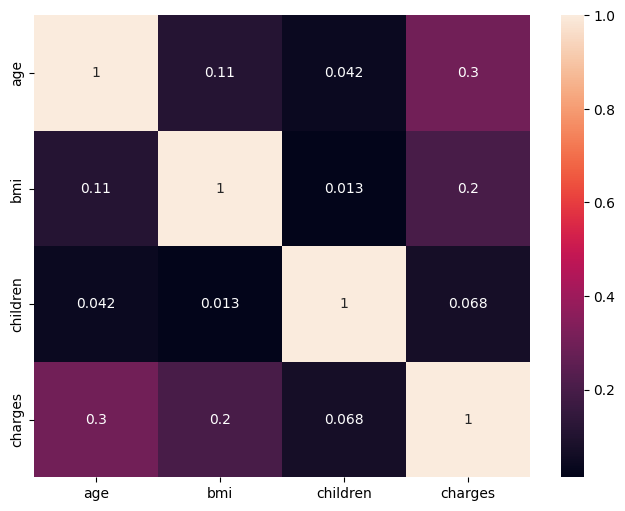

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

#data cleaning and preprocesing

In [16]:
data_cleaned=df.copy()

In [17]:
data_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [18]:
data_cleaned.shape

(1338, 7)

drop the duplicate value

In [19]:
data_cleaned.drop_duplicates(inplace=True)

In [20]:
data_cleaned.shape



(1337, 7)

find missing values

In [21]:
data_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

find data type 

In [22]:
data_cleaned.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

find value female and male use valuecounts() method

In [23]:
data_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

convert female and male vlaue in 0 and 1

In [24]:
data_cleaned['sex']=data_cleaned['sex'].map({'male':0,'female':1})

check the value again these values are converted or not

In [25]:
data_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,no,northwest,10600.54830
1334,18,1,31.920,0,no,northeast,2205.98080
1335,18,1,36.850,0,no,southeast,1629.83350
1336,21,1,25.800,0,no,southwest,2007.94500


same thing for smooker 

In [26]:
data_cleaned['smoker']=data_cleaned['smoker'].map({'yes':1,'no':0})

In [27]:
data_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


change columns name sex into male & female

In [28]:
data_cleaned.rename(columns={
    'sex':'male&female',
    'smoker':'is_smoker'
}, inplace=True)
data_cleaned

,age,male&female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


region change 

In [29]:
data_cleaned=pd.get_dummies(data_cleaned,columns=['region'],drop_first=True)

In [30]:
data_cleaned.head()

,age,male&female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [31]:
data_cleaned=data_cleaned.astype(int)
data_cleaned

,age,male&female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


feature engineering 

<Axes: xlabel='bmi', ylabel='Count'>

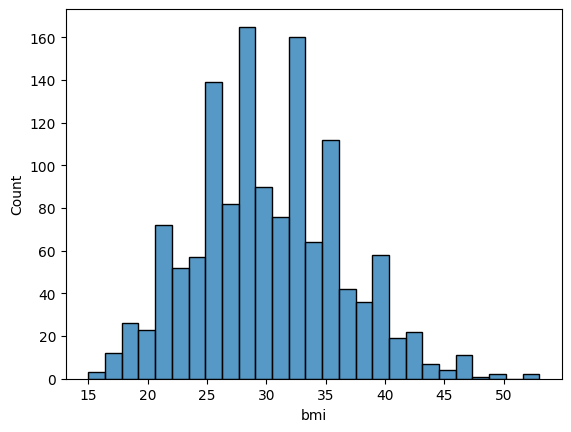

In [32]:
sns.histplot(data_cleaned['bmi'])

categorical bmi 

In [33]:
data_cleaned['bmi_categorical']=pd.cut(
    data_cleaned['bmi'],
    bins=[0,18.5,24.9,29.9,float('inf')],
    labels=['underweight','normal','overweight','obsese']
)

In [34]:
data_cleaned

,age,male&female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_categorical
0,19,1,27,0,1,16884,0,0,1,overweight
1,18,0,33,1,0,1725,0,1,0,obsese
2,28,0,33,3,0,4449,0,1,0,obsese
3,33,0,22,0,0,21984,1,0,0,normal
4,32,0,28,0,0,3866,1,0,0,overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,obsese
1334,18,1,31,0,0,2205,0,0,0,obsese
1335,18,1,36,0,0,1629,0,1,0,obsese
1336,21,1,25,0,0,2007,0,0,1,overweight


In [35]:
data_cleaned=pd.get_dummies(data_cleaned,columns=['bmi_categorical'],drop_first=True)

In [36]:
data_cleaned=data_cleaned.astype(int)
data_cleaned

,age,male&female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_categorical_normal,bmi_categorical_overweight,bmi_categorical_obsese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,0,0,1
1334,18,1,31,0,0,2205,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,1,0,0,0,1
1336,21,1,25,0,0,2007,0,0,1,0,1,0


In [37]:
from sklearn.preprocessing import StandardScaler
cols=['bmi','age','children'] 
scaler=StandardScaler()
data_cleaned[cols]=scaler.fit_transform(data_cleaned[cols])

In [38]:
data_cleaned

,age,male&female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_categorical_normal,bmi_categorical_overweight,bmi_categorical_obsese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,1,0,0,0,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,0,0,0,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,0,1,0,0,0,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0,1,0,1,0


In [41]:
print(data_cleaned.columns.tolist())

['age', 'male&female', 'bmi', 'children', 'is_smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_categorical_normal', 'bmi_categorical_overweight', 'bmi_categorical_obsese']


feature extraction

In [48]:
from scipy.stats import pearsonr

feature_selection=[
    'age','bmi', 'children',
    'is_smoker','region_northwest','region_southeast','region_southwest',
    'bmi_categorical_normal','bmi_categorical_overweight','bmi_categorical_obsese'
]

correlations = {
    feature_selection[i]: pearsonr(data_cleaned[feature_selection[i]], data_cleaned['charges'])[0]
    for i in range(len(feature_selection))
}
correlations=pd.DataFrame.from_dict(correlations, orient='index', columns=['Correlation_with_charges'])
correlations.sort_values(by='Correlation_with_charges', ascending=False)

,Correlation_with_charges
is_smoker,0.787234
age,0.298309
bmi_categorical_obsese,0.200348
bmi,0.196236
region_southeast,0.073577
children,0.067390
region_northwest,-0.038695
region_southwest,-0.043637
bmi_categorical_normal,-0.104042
bmi_categorical_overweight,-0.120601
